<a href="https://colab.research.google.com/github/MK545BH/IT7009-Project/blob/main/IT7009_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT7009 Project
## Part 1: Data preprocessing.
### Importing libraries and Data:


In [77]:
# importing all neccasary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# Importing the uncleaned "Raw" dataset.
RAW_PATH = "Dataset_Brief_2.csv"   # upload this file to the Colab session storage first
df_raw = pd.read_csv(RAW_PATH, low_memory=False) # added the file path to a constant for ease of use.

print("Raw dataset shape:", df_raw.shape) 
df_raw.head()


Raw dataset shape: (48826, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,4.835233,1713517.54,16.89,66.33,634.919224,634.919224,0.0,0.0,0.0,0.0,...,23.51914405190254,540.23,8.375931e+07,9.5,32.983477,31.837886,3663.34722,0.14,141.55,Mirai-udpplain
1,0.000000,54.0,6.0,64.00,2.671835,2.671835,0.0,0.0,1.0,0.0,...,0.0,54.0,8.297303e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DoS-SYN_Flood
2,0.000000,54.0,6.0,64.00,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,54.0,8.333120e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-PSHACK_Flood
3,0.000000,0.0,1.0,64.00,160.127665,160.127665,0.0,0.0,0.0,0.0,...,0.0,42.0,8.312889e+07,9.5,9.165151,0.000000,0.00000,0.0,141.55,DDoS-ICMP_Flood
4,0.000000,54.0,6.0,64.00,1.262448,1.262448,0.0,1.0,0.0,1.0,...,0.0,54.0,8.334516e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-RSTFINFlood


### Data Analysis

In [78]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   flow_duration    48815 non-null  float64
 1   Header_Length    48815 non-null  object 
 2   Protocol Type    48816 non-null  object 
 3   Duration         48816 non-null  float64
 4   Rate             48814 non-null  float64
 5   Srate            48816 non-null  float64
 6   Drate            48811 non-null  float64
 7   fin_flag_number  48814 non-null  float64
 8   syn_flag_number  48816 non-null  float64
 9   rst_flag_number  48815 non-null  float64
 10  psh_flag_number  48815 non-null  object 
 11  ack_flag_number  48814 non-null  float64
 12  ece_flag_number  48816 non-null  float64
 13  cwr_flag_number  48816 non-null  float64
 14  ack_count        48816 non-null  float64
 15  syn_count        48813 non-null  float64
 16  fin_count        48815 non-null  float64
 17  urg_count   

In [79]:
# Provides a detailed description of the data.
df_raw.describe(include='all').T.head(20) 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flow_duration,48815.0,NaN,NaN,NaN,14.495303,382.599894,-999.0,0.0,0.0,0.128624,47629.094561
Header_Length,48815,15623,54.0,14557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protocol Type,48816,915,6.0,22721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,48816.0,NaN,NaN,NaN,66.276401,12.9069,0.0,64.0,64.0,64.0,255.0
Rate,48814.0,NaN,NaN,NaN,8664.10689,89626.647942,-999.0,2.095422,15.69341,128.325003,3145728.0
Srate,48816.0,NaN,NaN,NaN,8663.824629,89624.823444,-999.0,2.095305,15.69341,128.351765,3145728.0
Drate,48811.0,NaN,NaN,NaN,0.000001,0.000089,0.0,0.0,0.0,0.0,0.014636
fin_flag_number,48814.0,NaN,NaN,NaN,0.083583,0.276764,0.0,0.0,0.0,0.0,1.0
syn_flag_number,48816.0,NaN,NaN,NaN,0.204359,0.403237,0.0,0.0,0.0,0.0,1.0
rst_flag_number,48815.0,NaN,NaN,NaN,0.088559,0.284109,0.0,0.0,0.0,0.0,1.0


### Data inspection:

In [80]:
# Isolate feature columns (exclude target)
features = df_raw.columns.drop('label')

# Flag identifier and timestamp columns (leakage risk)
id_like = features[features.str.contains(r'(?:^|_)(?:id|ip|mac|date|time|timestamp|session)(?:$|_)', case=False)]

# Print feature count and detected suspect columns
print(f"{len(features)} features | ID/date-like: {list(id_like) or 'None'}")

# Check target classes and missing labels
print(f"{df_raw['label'].nunique()} classes | missing labels: {df_raw['label'].isna().sum()}")

46 features | ID/date-like: None
33 classes | missing labels: 0


### Data type correction & missing value identification:

=== BEFORE CLEANING ===
Non-numeric columns:
12
Missing values:
520
Header_Length: ['invalid']
Protocol Type: ['invalid']
psh_flag_number: ['unknown']
rst_count: ['unknown']
HTTPS: ['unknown']
ICMP: ['invalid']
IPv: ['unknown']
LLC: ['unknown']
Min: ['unknown']
Std: ['unknown']
Tot size: ['unknown']
Variance: ['unknown']

=== AFTER CLEANING ===
Non-numeric columns:
0
Missing values:
532


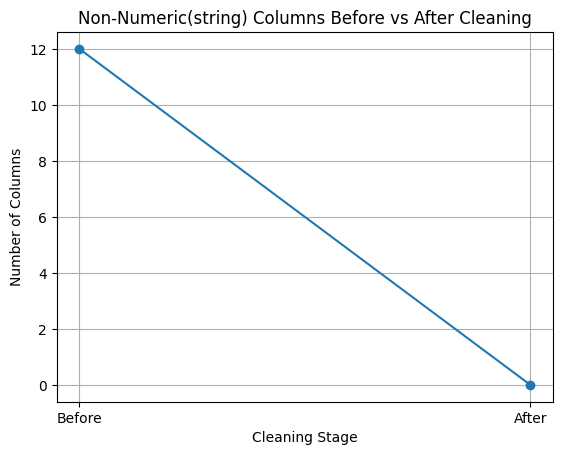

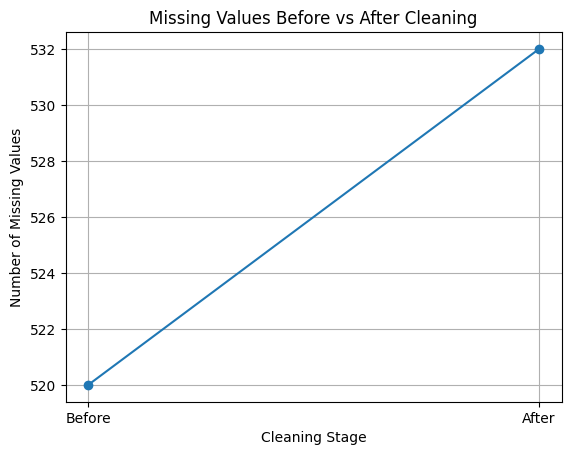

In [81]:
#creating a function for feature cleansing.
def clean_features(df, cols):
    df = df.copy()

    for col in cols:
        # 1. Convert once and store in a temporary variable
        numeric_series = pd.to_numeric(df[col], errors="coerce")
        
        # 2. Identify values that failed conversion (were NOT NaN originally, but are NaN now)
        failed_mask = numeric_series.isna() & df[col].notna()
        
        # 3. Log unique invalid values if any exist
        if failed_mask.any():
            print(f"{col}: {df.loc[failed_mask, col].unique().tolist()}")
        
        # 4. Assign the pre-converted series back to the DataFrame
        df[col] = numeric_series

    return df
# =============== BEFORE cleaning ===============
print("=== BEFORE CLEANING ===")

# Identify columns in the raw feature subset with string/object data types
non_numeric_before = df_raw[features].select_dtypes(
    include=["object"]
).columns.tolist()

# Calculate total missing (NaN/null) values across all feature columns
missing_before = df_raw[features].isna().sum().sum()

print("Non-numeric columns:")
print(len(non_numeric_before))
print("Missing values:")
print(missing_before)


# Clean the data
df = clean_features(df_raw, features)


# =============== AFTER cleaning ===============
print("\n=== AFTER CLEANING ===")

# Re-check for remaining string/object columns after numeric conversion
non_numeric_after = df[features].select_dtypes(
    include=["object"]
).columns.tolist()

# Re-calculate total missing values (coerced non-numeric values will increase this total)
missing_after = df[features].isna().sum().sum()

print("Non-numeric columns:")
print(len(non_numeric_after))

print("Missing values:")
print(missing_after)


# VISUALIZATION:

stages = ["Before", "After"]


# 1. Non-numeric columns
non_numeric = [
    len(non_numeric_before),
    len(non_numeric_after)
]

plt.plot(stages, non_numeric, marker="o")
plt.title("Non-Numeric(string) Columns Before vs After Cleaning")
plt.xlabel("Cleaning Stage")
plt.ylabel("Number of Columns")
plt.grid(True)
plt.show()


# 2. Missing values
missing = [
    missing_before,
    missing_after
]

plt.plot(stages, missing, marker="o")
plt.title("Missing Values Before vs After Cleaning")
plt.xlabel("Cleaning Stage")
plt.ylabel("Number of Missing Values")
plt.grid(True)
plt.show()

### Removing Duplicates:

Exact duplicate rows found: 40
Shape before removing duplicates: (48826, 47)
Shape after removing duplicates: (48786, 47)


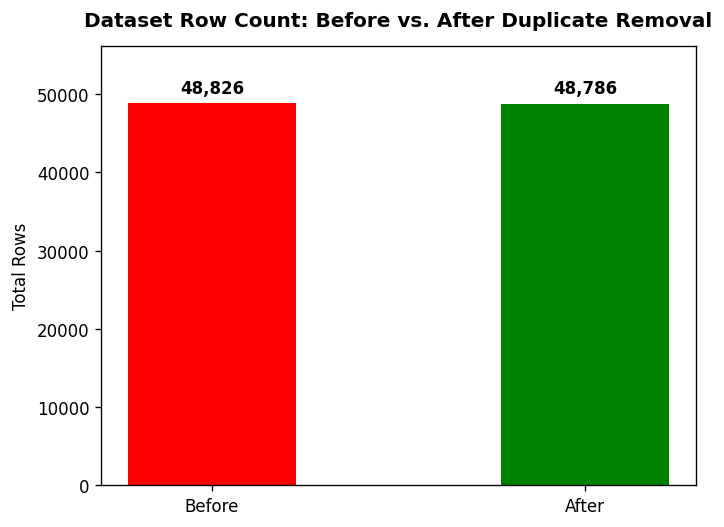

In [82]:
# Count total duplicate rows
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {n_dupes}")
print(f"Shape before removing duplicates: {df.shape}")

# 1. Store counts correctly BEFORE dropping duplicates
rows_before = len(df)
n_dupes = df.duplicated().sum()

# Drop duplicates
df = df.drop_duplicates(keep="first").reset_index(drop=True)
rows_after = len(df)
# Print final dataset dimensions (rows, columns)
print(f"Shape after removing duplicates: {df.shape}")

# Visualization of duplicate rows before and after removal
# 2. Data setup
stages = ["Before", "After"]
row_counts = [rows_before, rows_after]
colors = ["red", "green"]

# 3. Create plot
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=120)
bars = ax.bar(stages, row_counts, color=colors, width=0.45, zorder=2)

#Use f-string lambda function for formatting integers with commas
ax.bar_label(bars, labels=[f"{x:,}" for x in row_counts], padding=4, fontweight='bold', fontsize=10)

# Styling and titles
ax.set_title("Dataset Row Count: Before vs. After Duplicate Removal", fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Total Rows", fontsize=10)

# Add y-axis margin so text labels aren't cut off at top
ax.set_ylim(0, max(row_counts) * 1.15)

plt.tight_layout()
plt.show()